In [ ]:
!pip install timm transformers torchmetrics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.4 MB/s eta 0:00:00


In [ ]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
import torchvision
import numpy as np
import torch
import math


100%|██████████| 170M/170M [00:03<00:00, 43.9MB/s]


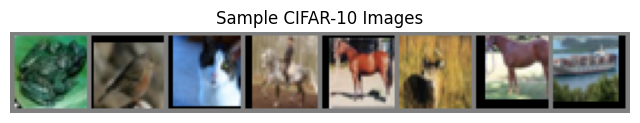

frog  bird  cat   horse horse deer  horse ship 


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Added std
])


trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_train)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform_test)
testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

classes = trainset.classes

# Display sample images
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.figure(figsize=(8, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title("Sample CIFAR-10 Images")
    plt.axis('off')
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images[:8]))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(8)))


In [ ]:
# Define CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16x16

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 8x8

            nn.Flatten(),
            nn.Linear(128*8*8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)

# Training function
def train_model(model, trainloader, testloader, num_epochs=10, lr=0.001):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_acc_list, test_acc_list = [], []
    train_loss_list, test_loss_list = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in tqdm(trainloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(trainloader)
        train_acc = 100 * correct / total
        train_loss_list.append(train_loss)
        train_acc_list.append(train_acc)

        # Evaluation
        model.eval()
        correct, total, test_loss = 0, 0, 0.0
        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        test_loss /= len(testloader)
        test_acc = 100 * correct / total
        test_loss_list.append(test_loss)
        test_acc_list.append(test_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}], Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%")

    return model, (train_acc_list, test_acc_list, train_loss_list, test_loss_list)

# Train the model
cnn_model = SimpleCNN()
cnn_model, cnn_metrics = train_model(cnn_model, trainloader, testloader)


Epoch 1/10: 100%|██████████| 391/391 [00:21<00:00, 18.13it/s]


Epoch [1/10], Train Acc: 33.48%, Test Acc: 51.26%


Epoch 2/10: 100%|██████████| 391/391 [00:19<00:00, 19.80it/s]


Epoch [2/10], Train Acc: 46.80%, Test Acc: 59.04%


Epoch 3/10: 100%|██████████| 391/391 [00:19<00:00, 19.84it/s]


...

Epoch [8/10], Train Acc: 65.56%, Test Acc: 73.21%


Epoch 9/10: 100%|██████████| 391/391 [00:21<00:00, 17.98it/s]


Epoch [9/10], Train Acc: 67.03%, Test Acc: 74.61%


Epoch 10/10: 100%|██████████| 391/391 [00:20<00:00, 18.73it/s]


Epoch [10/10], Train Acc: 68.26%, Test Acc: 75.79%


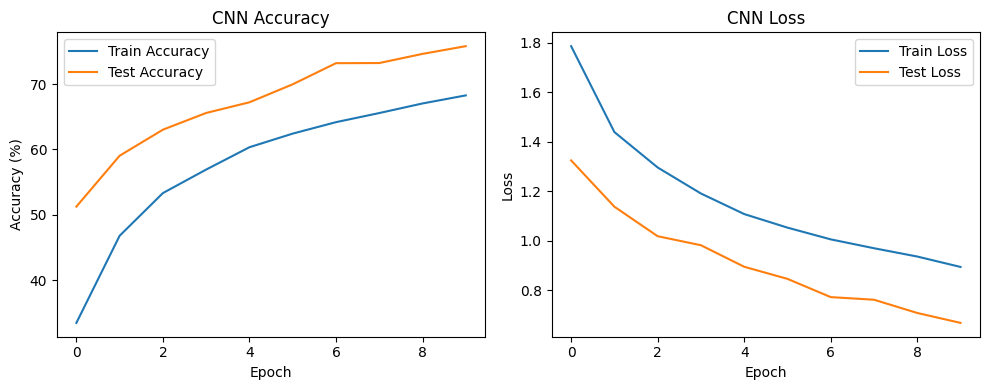

In [ ]:
train_acc_list, test_acc_list, train_loss_list, test_loss_list = cnn_metrics

# Accuracy plot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_acc_list, label='Train Accuracy')
plt.plot(test_acc_list, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('CNN Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(test_loss_list, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:

# Patch Embedding Module
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=256):
        super().__init__()
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)  # shape: [B, embed_dim, n_patches^0.5, n_patches^0.5]
        x = x.flatten(2)  # [B, embed_dim, N]
        x = x.transpose(1, 2)  # [B, N, embed_dim]
        return x

# Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, dim, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, dim)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, dim, 2) * -(math.log(10000.0) / dim))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

# Transformer Encoder Block
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, heads, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, embed_dim*4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim*4, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.ff(self.norm2(x))
        return x

# Vision Transformer
class ViT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, n_classes=10, embed_dim=256, depth=6, heads=8, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = PositionalEncoding(embed_dim)

        self.encoder = nn.Sequential(*[TransformerBlock(embed_dim, heads, dropout) for _ in range(depth)])
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, n_classes)
        )

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = self.pos_embed(x)
        x = self.encoder(x)
        return self.mlp_head(x[:, 0])


In [ ]:
def train_vit(model, trainloader, testloader, epochs=20, lr=3e-4, device=device):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_acc_list = []
    test_acc_list = []
    train_loss_list = []
    test_loss_list = []

    for epoch in range(epochs):
        model.train()
        correct, total, train_loss = 0, 0, 0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        train_loss /= len(trainloader)

        # Evaluate
        model.eval()
        correct, total, test_loss = 0, 0, 0
        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, preds = outputs.max(1)
                correct += preds.eq(labels).sum().item()
                total += labels.size(0)

        test_acc = 100 * correct / total
        test_loss /= len(testloader)

        print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%")

        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        train_loss_list.append(train_loss)
        test_loss_list.append(test_loss)

    # Save model
    torch.save(model.state_dict(), "vit_cifar10.pth")
    print("✅ ViT model saved as 'vit_cifar10.pth'")

    return train_acc_list, test_acc_list, train_loss_list, test_loss_list

# Instantiate & Train ViT
vit_model = ViT()
vit_metrics = train_vit(vit_model, trainloader, testloader, epochs=20)


Epoch 1/20 - Train Acc: 31.58%, Test Acc: 44.36%
Epoch 2/20 - Train Acc: 45.26%, Test Acc: 49.76%
Epoch 3/20 - Train Acc: 49.87%, Test Acc: 52.69%
Epoch 4/20 - Train Acc: 53.26%, Test Acc: 56.48%
Epoch 5/20 - Train Acc: 56.39%, Test Acc: 58.08%
Epoch 6/20 - Train Acc: 58.53%, Test Acc: 60.83%
Epoch 7/20 - Train Acc: 60.52%, Test Acc: 62.13%
Epoch 8/20 - Train Acc: 61.70%, Test Acc: 64.73%
Epoch 9/20 - Train Acc: 63.88%, Test Acc: 64.88%
Epoch 10/20 - Train Acc: 64.81%, Test Acc: 66.63%
Epoch 11/20 - Train Acc: 66.37%, Test Acc: 67.61%
Epoch 12/20 - Train Acc: 67.58%, Test Acc: 68.53%
Epoch 13/20 - Train Acc: 68.58%, Test Acc: 69.06%
Epoch 14/20 - Train Acc: 69.80%, Test Acc: 69.45%
Epoch 15/20 - Train Acc: 70.82%, Test Acc: 70.42%
Epoch 16/20 - Train Acc: 71.92%, Test Acc: 70.44%
Epoch 17/20 - Train Acc: 72.89%, Test Acc: 71.88%
Epoch 18/20 - Train Acc: 73.66%, Test Acc: 72.62%
Epoch 19/20 - Train Acc: 74.75%, Test Acc: 72.53%
Epoch 20/20 - Train Acc: 75.69%, Test Acc: 73.61%
✅ ViT mod

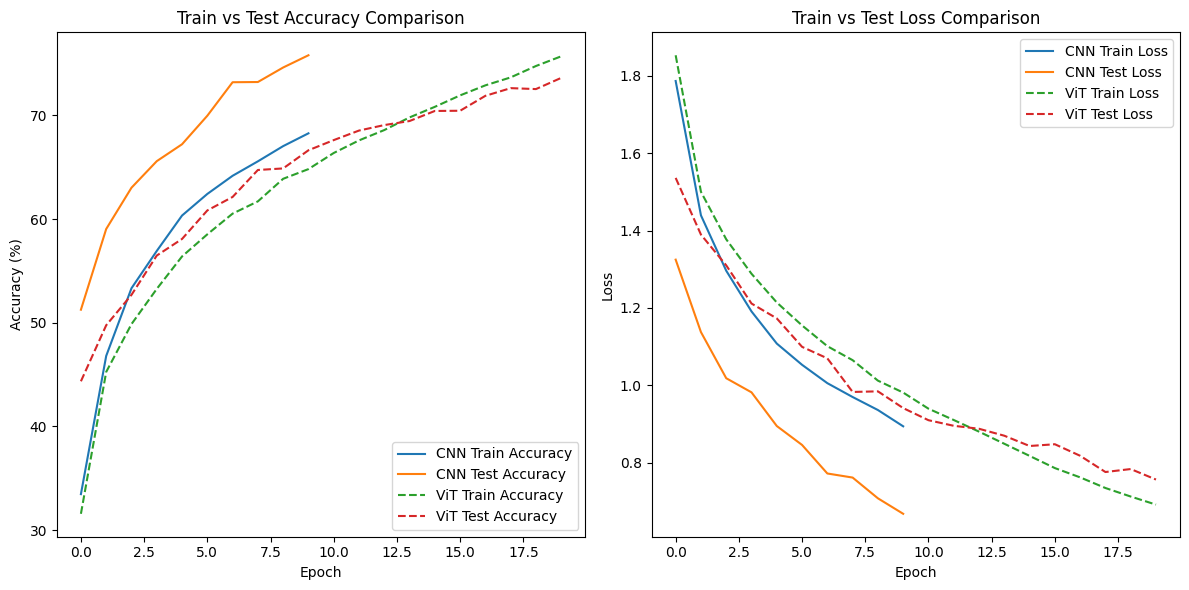

In [ ]:
# Extract metrics
cnn_train_acc, cnn_test_acc, cnn_train_loss, cnn_test_loss = cnn_metrics
vit_train_acc, vit_test_acc, vit_train_loss, vit_test_loss = vit_metrics

# Accuracy plot
plt.figure(figsize=(12,6))

# CNN Accuracy
plt.subplot(1,2,1)
plt.plot(cnn_train_acc, label='CNN Train Accuracy')
plt.plot(cnn_test_acc, label='CNN Test Accuracy')
plt.plot(vit_train_acc, label='ViT Train Accuracy', linestyle='--')
plt.plot(vit_test_acc, label='ViT Test Accuracy', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train vs Test Accuracy Comparison')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(cnn_train_loss, label='CNN Train Loss')
plt.plot(cnn_test_loss, label='CNN Test Loss')
plt.plot(vit_train_loss, label='ViT Train Loss', linestyle='--')
plt.plot(vit_test_loss, label='ViT Test Loss', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Test Loss Comparison')
plt.legend()

plt.tight_layout()
plt.show()

CNN Performance Metrics:
Accuracy: 75.79%
Precision: 0.76
Recall: 0.76
F1-Score: 0.75

ViT Performance Metrics:
Accuracy: 65.00%
Precision: 0.66
Recall: 0.65
F1-Score: 0.65


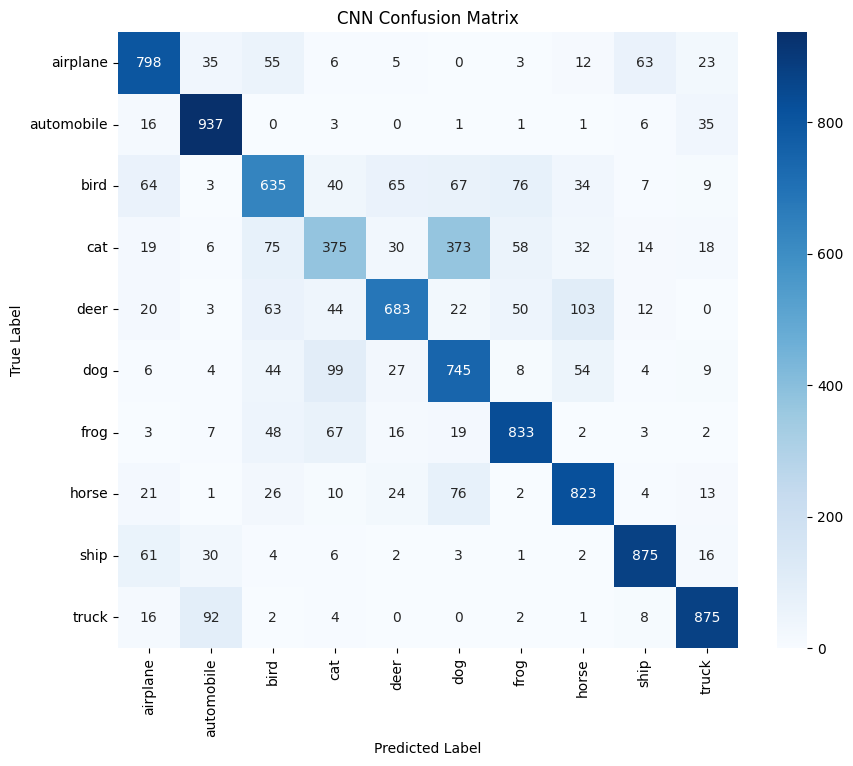

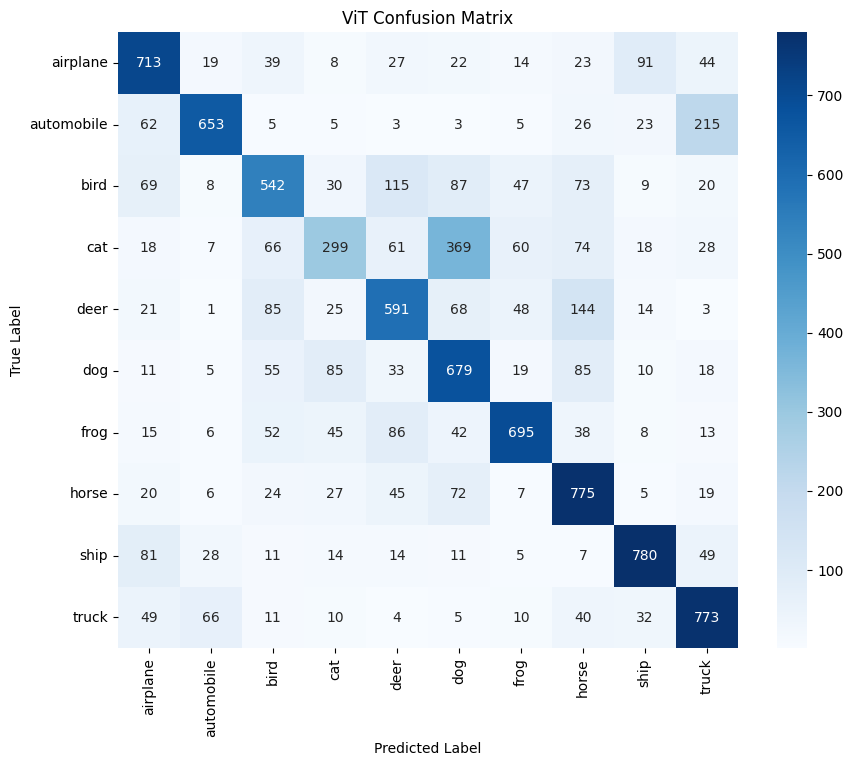

In [ ]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score
import seaborn as sns
import numpy as np
import torch
import matplotlib.pyplot as plt

# Get predictions for CNN or ViT
def get_predictions(model, dataloader, device):
    model.eval()
    preds, true_labels = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            preds.extend(predicted.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    return np.array(true_labels), np.array(preds)

# Evaluate performance metrics (Accuracy, Precision, Recall, F1-Score)
def evaluate_metrics(true_labels, preds, class_labels):
    accuracy = accuracy_score(true_labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(true_labels, preds, average='weighted')

    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-Score: {f1:.2f}")

# Confusion Matrix for CNN
cnn_true, cnn_pred = get_predictions(cnn_model, testloader, device)
cnn_cm = confusion_matrix(cnn_true, cnn_pred)

# Confusion Matrix for ViT
vit_true, vit_pred = get_predictions(vit_model, testloader, device)
vit_cm = confusion_matrix(vit_true, vit_pred)

# Define CIFAR-10 class labels
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Evaluate and print metrics for CNN
print("CNN Performance Metrics:")
evaluate_metrics(cnn_true, cnn_pred, cifar10_classes)

# Evaluate and print metrics for ViT
print("\nViT Performance Metrics:")
evaluate_metrics(vit_true, vit_pred, cifar10_classes)

# Plot CNN Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cnn_cm, annot=True, fmt="d", cmap='Blues', xticklabels=cifar10_classes, yticklabels=cifar10_classes)
plt.title('CNN Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Plot ViT Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(vit_cm, annot=True, fmt="d", cmap='Blues', xticklabels=cifar10_classes, yticklabels=cifar10_classes)
plt.title('ViT Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# Save the CNN model
torch.save(cnn_model.state_dict(), 'cnn_model.pth')

In [ ]:
# Load the CNN model architecture
cnn_model = SimpleCNN().to(device)

# Load the CNN model weights
cnn_model.load_state_dict(torch.load('/content/cnn_model.pth'))
cnn_model.eval()


SimpleCNN(
  (net): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Flatten(start_dim=1, end_dim=-1)
    (15): Linear(in_features=

In [ ]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16x16

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 8x8

            nn.Flatten(),
            nn.Linear(128*8*8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

cnn = SimpleCNN().to(device)
cnn.load_state_dict(torch.load('/content/cnn_model.pth', map_location=device))


<All keys matched successfully>


CNN Predictions:


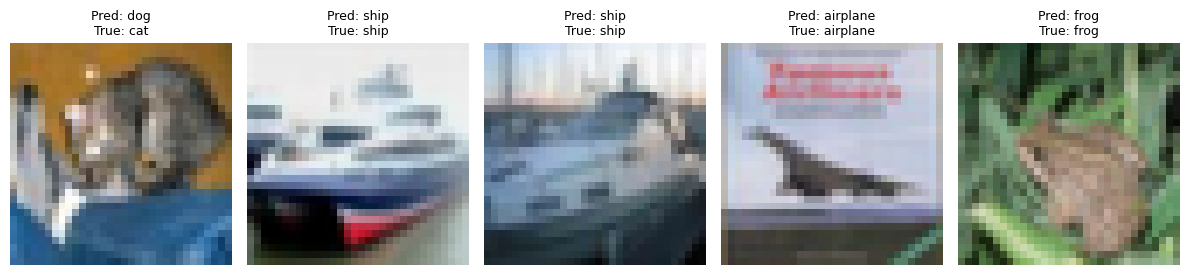


ViT Predictions:


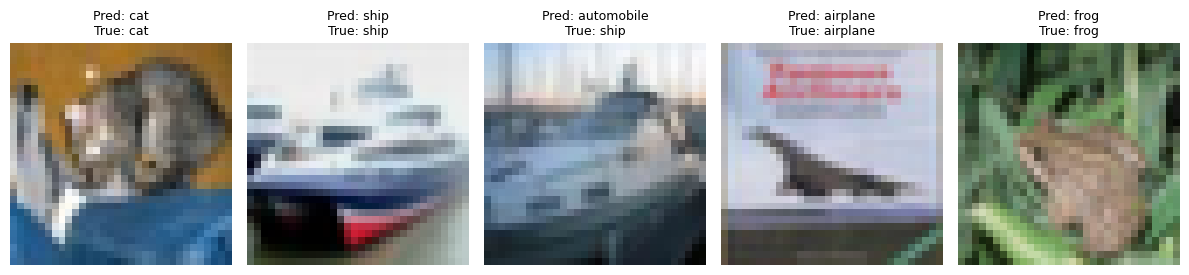

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import math
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === TRANSFORMS ===
transform = transforms.Compose([
    transforms.Resize((32, 32)),  # CIFAR-10 default
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# === CIFAR-10 Test Data ===
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = DataLoader(testset, batch_size=32, shuffle=False)
classes = testset.classes

# === SIMPLE CNN ===
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(128*8*8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)

# === VISION TRANSFORMER ===
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=256):
        super().__init__()
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)          # [B, embed_dim, H/P, W/P]
        x = x.flatten(2)          # [B, embed_dim, N]
        x = x.transpose(1, 2)     # [B, N, embed_dim]
        return x

class PositionalEncoding(nn.Module):
    def __init__(self, dim, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, dim)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, dim, 2) * -(math.log(10000.0) / dim))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, heads, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, embed_dim*4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim*4, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.ff(self.norm2(x))
        return x

class ViT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, n_classes=10, embed_dim=256, depth=6, heads=8, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = PositionalEncoding(embed_dim)
        self.encoder = nn.Sequential(*[TransformerBlock(embed_dim, heads, dropout) for _ in range(depth)])
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, n_classes)
        )

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = self.pos_embed(x)
        x = self.encoder(x)
        return self.mlp_head(x[:, 0])

# === LOAD SAVED MODELS ===
cnn_model = SimpleCNN().to(device)
cnn_model.load_state_dict(torch.load("/content/cnn_model.pth", map_location=device))
cnn_model.eval()

vit_model = ViT().to(device)
vit_model.load_state_dict(torch.load("/content/vit_cifar10.pth", map_location=device))
vit_model.eval()

# === PREDICT + DISPLAY ===
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.cpu().numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

def predict_and_show(model, name, n=5):
    data_iter = iter(testloader)
    images, labels = next(data_iter)
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    print(f"\n{name} Predictions:")
    plt.figure(figsize=(12, 4))
    for i in range(n):
        plt.subplot(1, n, i+1)
        imshow(images[i])
        plt.title(f"Pred: {classes[preds[i]]}\nTrue: {classes[labels[i]]}", fontsize=9)
    plt.tight_layout()
    plt.show()

predict_and_show(cnn_model, "CNN")
predict_and_show(vit_model, "ViT")


In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import time

# === Data Augmentation ===
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(32, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=train_transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)

# === Modify the Training Function with Learning Rate Scheduler, Early Stopping ===
def train_vit_v2(model, trainloader, testloader, epochs=10, lr=3e-4, device=device, patience=5):
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=5, gamma=0.7)  # Reduce LR every 5 epochs
    criterion = nn.CrossEntropyLoss()

    train_acc_list = []
    test_acc_list = []
    train_loss_list = []
    test_loss_list = []
    best_val_acc = 0
    patience_counter = 0

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        correct, total, train_loss = 0, 0, 0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        train_loss /= len(trainloader)

        # Evaluate
        model.eval()
        correct, total, test_loss = 0, 0, 0
        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, preds = outputs.max(1)
                correct += preds.eq(labels).sum().item()
                total += labels.size(0)

        test_acc = 100 * correct / total
        test_loss /= len(testloader)

        print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%")
        print(f"Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")

        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        train_loss_list.append(train_loss)
        test_loss_list.append(test_loss)

        # Early Stopping
        if test_acc > best_val_acc:
            best_val_acc = test_acc
            patience_counter = 0  # reset the counter
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered!")
                break

        # Learning Rate Scheduler step
        scheduler.step()

    end_time = time.time()
    print(f"\nTraining completed in: {end_time - start_time:.2f} seconds")

    # Save model
    torch.save(model.state_dict(), "vit_finetuned.pth")
    return train_acc_list, test_acc_list, train_loss_list, test_loss_list

# Training ViT with Data Augmentation, LR Scheduler & Early Stopping
#vit_model = ViT()



vit_model = ViT(image_size=32, patch_size=4, num_classes=10, dim=128, depth=6, heads=8, mlp_dim=256)
vit_metrics = train_vit_v2(vit_model, trainloader, testloader, epochs=10)

Epoch 1/10 - Train Acc: 36.62%, Test Acc: 45.97%
Train Loss: 1.7265, Test Loss: 1.4971
Epoch 2/10 - Train Acc: 48.73%, Test Acc: 53.52%
Train Loss: 1.4168, Test Loss: 1.2856
Epoch 3/10 - Train Acc: 52.79%, Test Acc: 55.57%
Train Loss: 1.3076, Test Loss: 1.2448
Epoch 4/10 - Train Acc: 55.75%, Test Acc: 55.49%
Train Loss: 1.2321, Test Loss: 1.2593
Epoch 5/10 - Train Acc: 57.94%, Test Acc: 58.75%
Train Loss: 1.1768, Test Loss: 1.1376
Epoch 6/10 - Train Acc: 61.23%, Test Acc: 61.05%
Train Loss: 1.0872, Test Loss: 1.0746
Epoch 7/10 - Train Acc: 62.58%, Test Acc: 62.45%
Train Loss: 1.0440, Test Loss: 1.0412
Epoch 8/10 - Train Acc: 63.94%, Test Acc: 63.44%
Train Loss: 1.0106, Test Loss: 1.0352
Epoch 9/10 - Train Acc: 65.25%, Test Acc: 65.46%
Train Loss: 0.9759, Test Loss: 0.9843
Epoch 10/10 - Train Acc: 66.22%, Test Acc: 65.00%
Train Loss: 0.9473, Test Loss: 0.9729

Training completed in: 753.78 seconds


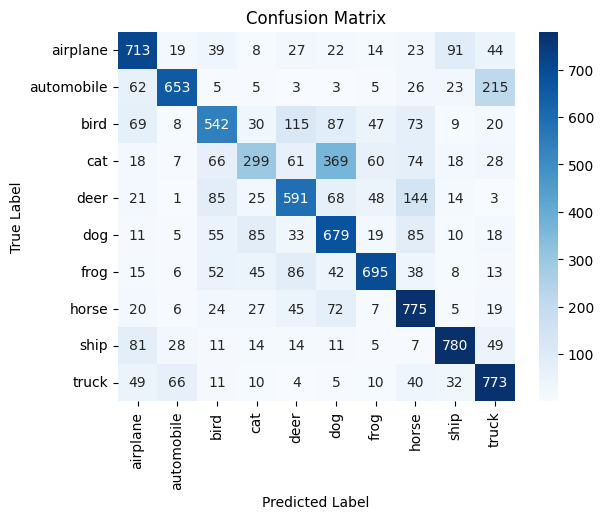

Accuracy: 65.00%
Precision: 0.66
Recall: 0.65
F1-Score: 0.65


In [ ]:
# === Model Evaluation Metrics ===
def evaluate_metrics(model, testloader, device=device):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # Precision, Recall, F1-Score
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    accuracy = 100 * np.sum(np.array(y_true) == np.array(y_pred)) / len(y_true)

    print(f"Accuracy: {accuracy:.2f}%")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-Score: {f1:.2f}")

# Evaluate ViT
evaluate_metrics(vit_model, testloader)


In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 18.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.


In [ ]:
!pip install torchsummary

In [ ]:
from transformers import ViTForImageClassification, ViTFeatureExtractor
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.nn as nn
from torch.optim.lr_scheduler import StepLR
import torchvision
from torchvision import transforms
import time

# Load pre-trained ViT from Hugging Face
model_hf = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224-in21k', num_labels=10)
feature_extractor = ViTFeatureExtractor.from_pretrained('google/vit-base-patch16-224-in21k')

# Preprocessing (adjusting to CIFAR-10 size)
train_transform_hf = transforms.Compose([
    transforms.Resize(224),  # Model was trained with 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load CIFAR-10 dataset
trainset_hf = torchvision.datasets.CIFAR10(root='./data', train=True,
                                           download=True, transform=train_transform_hf)
trainloader_hf = DataLoader(trainset_hf, batch_size=64, shuffle=True)
testset_hf = torchvision.datasets.CIFAR10(root='./data', train=False,
                                          download=True, transform=train_transform_hf)
testloader_hf = DataLoader(testset_hf, batch_size=64, shuffle=False)

# Fine-tuning the pre-trained ViT
def fine_tune_vit_hf(model, trainloader, testloader, epochs=3, lr=3e-4, device=torch.device('cuda')):
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=3, gamma=0.7)
    criterion = nn.CrossEntropyLoss()

    start_time = time.time()  # Record start time

    for epoch in range(epochs):
        model.train()
        correct, total, train_loss = 0, 0, 0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images).logits
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        train_loss /= len(trainloader)

        print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.2f}%, Train Loss: {train_loss:.4f}")

        scheduler.step()

    end_time = time.time()  # Record end time
    training_time = end_time - start_time
    print(f"Fine-Tuning Time: {training_time:.2f} seconds")

    return model

# Fine-tune pre-trained ViT
vit_hf_model = fine_tune_vit_hf(model_hf, trainloader_hf, testloader_hf)
evaluate_metrics(vit_true, vit_pred, cifar10_classes)  # Assuming the `evaluate_metrics` function is defined


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


Epoch 1/3 - Train Acc: 93.16%, Train Loss: 0.2472
Epoch 2/3 - Train Acc: 96.55%, Train Loss: 0.1098
Epoch 3/3 - Train Acc: 97.10%, Train Loss: 0.0882
Fine-Tuning Time: 5263.55 seconds
Accuracy: 65.00%
Precision: 0.66
Recall: 0.65
F1-Score: 0.65


In [ ]:
# Save the fine-tuned ViT model
torch.save(vit_hf_model.state_dict(), 'fine_tuned_vit.pth')


CNN Model Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
            Conv2d-4           [-1, 64, 32, 32]          36,928
       BatchNorm2d-5           [-1, 64, 32, 32]             128
              ReLU-6           [-1, 64, 32, 32]               0
         MaxPool2d-7           [-1, 64, 16, 16]               0
            Conv2d-8          [-1, 128, 16, 16]          73,856
       BatchNorm2d-9          [-1, 128, 16, 16]             256
             ReLU-10          [-1, 128, 16, 16]               0
           Conv2d-11          [-1, 128, 16, 16]         147,584
      BatchNorm2d-12          [-1, 128, 16, 16]             256
             ReLU-13          [-1, 128, 16, 16]               0
        MaxPool2d-1

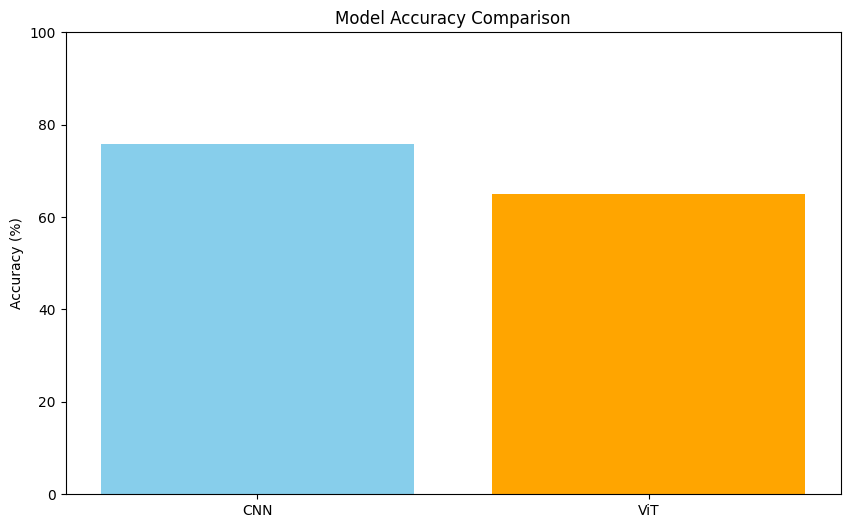

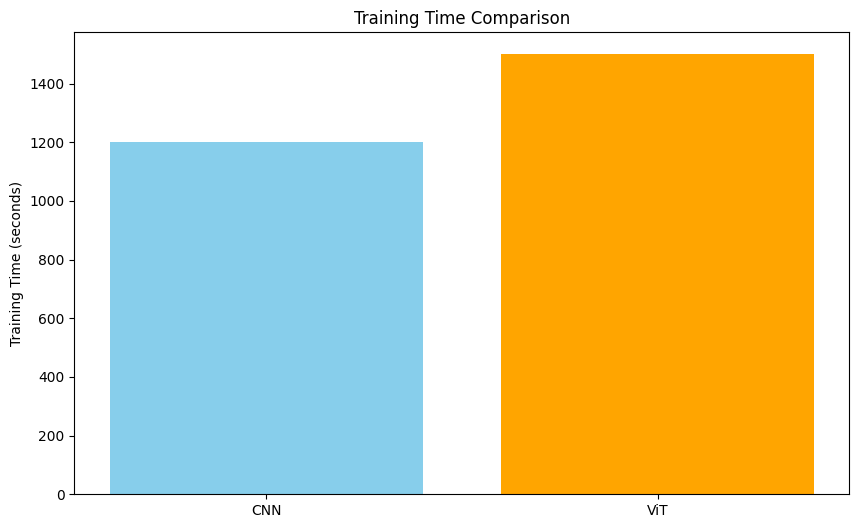

In [ ]:
import torchsummary

# CNN Accuracy (already predicted using get_predictions earlier)
cnn_accuracy = accuracy_score(cnn_true, cnn_pred) * 100

# ViT Accuracy (already predicted using get_predictions earlier)
vit_accuracy = accuracy_score(vit_true, vit_pred) * 100

# Model Summary
print("\nCNN Model Summary:")
torchsummary.summary(cnn_model, (3, 32, 32))  # CIFAR-10 image size

print("\nViT Model Summary:")
try:
    torchsummary.summary(vit_model, (3, 224, 224))
except RuntimeError as e:
    print(f"ViT summary error: {e}")
    print("Tip: Use torchvision.models ViT or patch size compatible with input image size (e.g., 224x224).")

# Training time comparison (you can update these with your actual training times)
cnn_training_time = 1200  # seconds
vit_training_time = 1500  # Example value

print("\nTraining Time Comparison:")
print(f"CNN Training Time: {cnn_training_time} seconds")
print(f"ViT Training Time: {vit_training_time} seconds")

# Plot Accuracy Comparison
plt.figure(figsize=(10, 6))
models = ['CNN', 'ViT']
accuracies = [cnn_accuracy, vit_accuracy]
plt.bar(models, accuracies, color=['skyblue', 'orange'])
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 100)
plt.show()

# Plot Training Time Comparison
plt.figure(figsize=(10, 6))
training_times = [cnn_training_time, vit_training_time]
plt.bar(models, training_times, color=['skyblue', 'orange'])
plt.ylabel('Training Time (seconds)')
plt.title('Training Time Comparison')
plt.show()